Dataset Overview
Total records: 8786
Total features: 33

Feature list:
- console
- genre
- publisher
- developer
- critic_score
- total_sales
- na_sales
- jp_sales
- pal_sales
- other_sales
- release_date
- total_sales_outlier
- na_sales_outlier
- jp_sales_outlier
- pal_sales_outlier
- other_sales_outlier
- sales_cluster
- log_sales
- total_sales_minmax
- na_sales_minmax
- jp_sales_minmax
- pal_sales_minmax
- other_sales_minmax
- critic_score_zscore
- release_year
- release_year_bin
- na_ratio
- jp_ratio
- pal_ratio
- other_ratio
- has_regional_data
- publisher_game_count
- developer_game_count

First 5 rows:
  console   genre     publisher          developer  critic_score  total_sales  \
0     PS3  ACTION       UBISOFT  UBISOFT BUCHAREST           7.5         0.41   
1      DS  ACTION       UBISOFT   UBISOFT MONTREAL           7.3         0.31   
2     WII  ACTION    ACTIVISION                MTO           7.5         0.67   
3     PSV  ACTION  IDEA FACTORY            UNKNOWN         

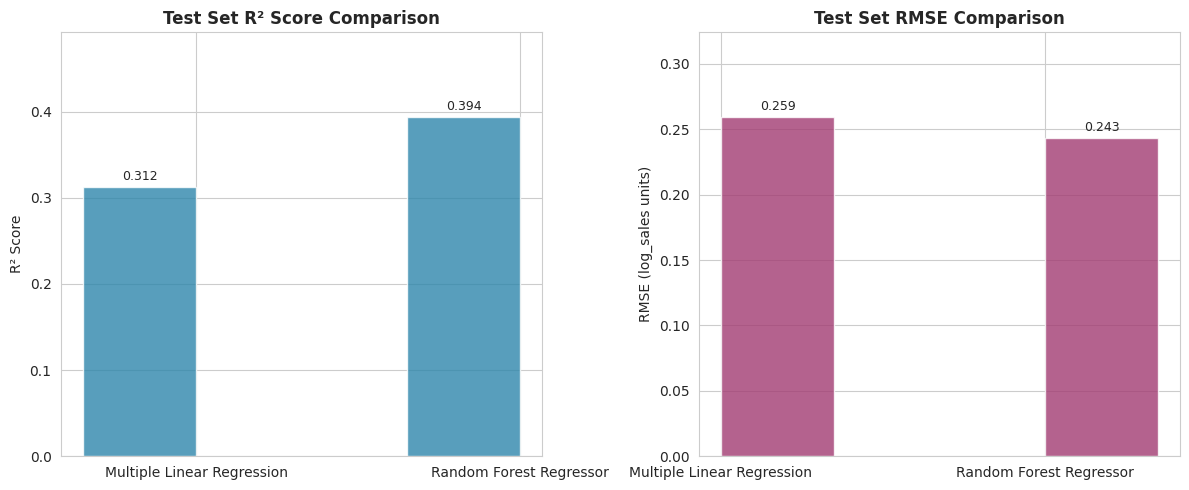

C:\Users\lenovo\AppData\Local\Temp\ipykernel_112340\578382527.py:255: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


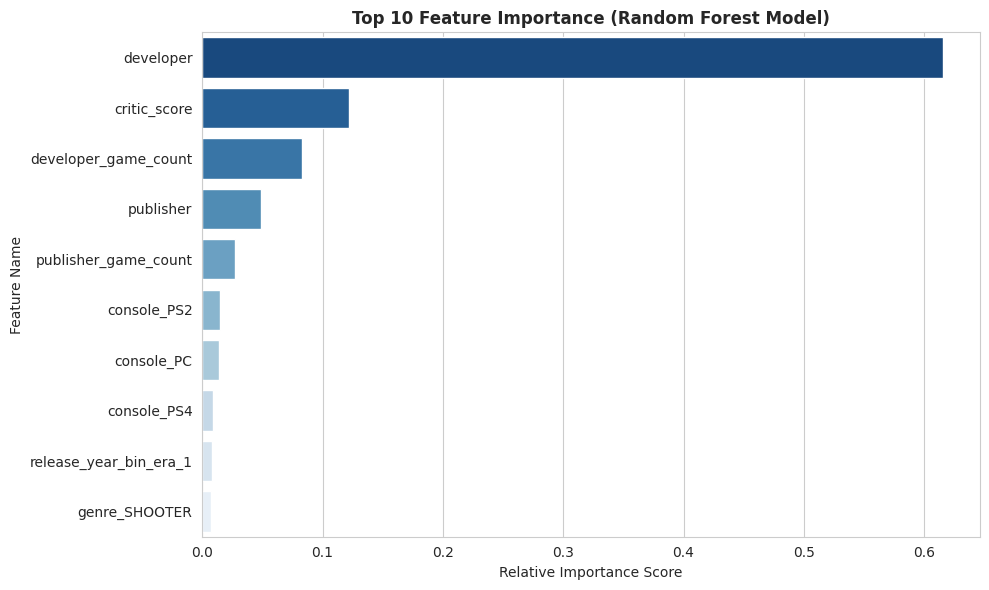

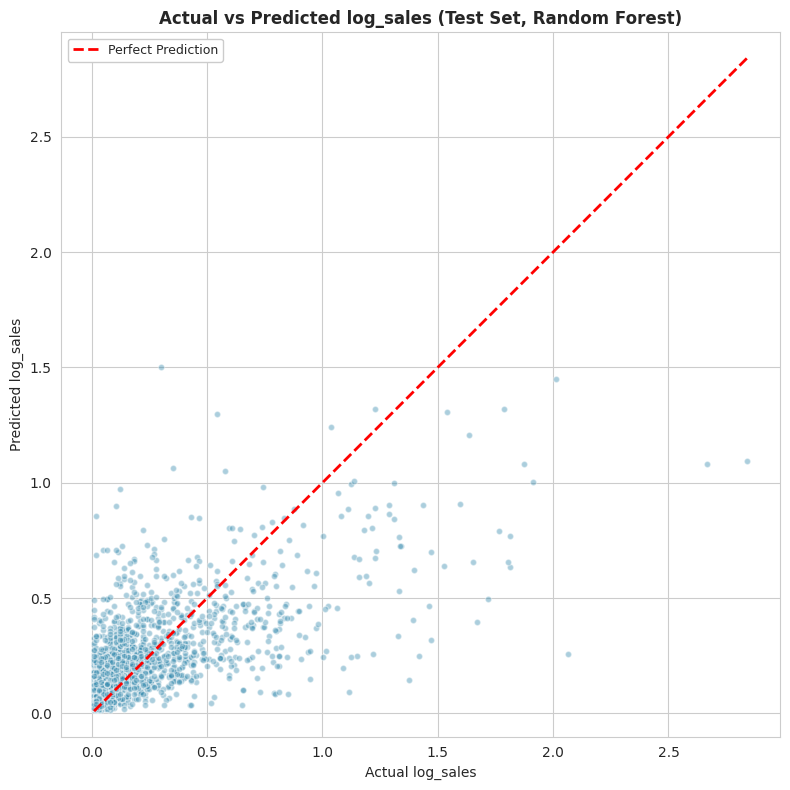


Analysis Completed
All visualisations and result files have been saved to the current directory.


In [4]:
# ==============================================================
# M5 Video Game Sales Prediction - Complete Code Notebook
# Dataset: cleaned_vgchartz.csv
# Course: INFO422 Data Science
# ==============================================================

# --------------------------
# 1. Install & Import Required Libraries
# --------------------------
# Uncomment to install required packages
# !pip install pandas numpy scikit-learn category_encoders matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Set global visualization style
sns.set_style("whitegrid")
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 10

# --------------------------
# 2. Load & Inspect Dataset
# --------------------------
# Load the cleaned VGChartz dataset
df = pd.read_csv("cleaned_vgchartz.csv")

# Inspect dataset structure
print("="*50)
print("Dataset Overview")
print("="*50)
print(f"Total records: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")
print("\nFeature list:")
for col in df.columns:
    print(f"- {col}")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset info:")
print(df.info())

# --------------------------
# 3. Preprocessing & Feature Engineering
# --------------------------
# 3.1 Define features and target
# Target variable: log_sales (log-transformed total sales)
target_col = "log_sales"

# Input features (no leakage, exclude regional sales columns)
feature_cols = [
    "console", "genre", "publisher", "developer",
    "critic_score", "release_year_bin",
    "publisher_game_count", "developer_game_count"
]

# Filter dataset to only include required features and target
df_model = df[feature_cols + [target_col]].copy()

# 3.2 Handle rare categories (merge <1% frequency genres into "Other")
genre_frequency = df_model["genre"].value_counts(normalize=True)
rare_genres = genre_frequency[genre_frequency < 0.01].index
df_model["genre"] = df_model["genre"].replace(rare_genres, "Other")

# 3.3 Train-test split (80% train, 20% test, stratified by genre)
X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=df_model["genre"]
)

print("\n" + "="*50)
print("Train-Test Split Summary")
print("="*50)
print(f"Training set: {X_train.shape[0]} records")
print(f"Test set: {X_test.shape[0]} records")

# 3.4 Define feature groups for encoding
# Low-cardinality categorical features (One-Hot Encoding)
low_card_cat = ["console", "genre", "release_year_bin"]
# High-cardinality categorical features (Target Encoding)
high_card_cat = ["publisher", "developer"]
# Numerical features (Standard Scaling)
num_features = ["critic_score", "publisher_game_count", "developer_game_count"]

# 3.5 Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), low_card_cat),
        ("target_enc", TargetEncoder(smoothing=10), high_card_cat),
        ("scaler", StandardScaler(), num_features)
    ],
    remainder="drop"
)

# --------------------------
# 4. Model Training & Cross-Validation
# --------------------------
# 4.1 Define models
model_library = {
    "Multiple Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )
}

# 4.2 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("\n" + "="*50)
print("5-Fold Cross-Validation Results")
print("="*50)
print(f"{'Model':<25} | {'R² Mean':>8} | {'RMSE Mean':>10} | {'MAE Mean':>9}")
print("-"*50)

for model_name, model in model_library.items():
    # Build full pipeline (preprocessing + model)
    full_pipeline = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    # Calculate cross-validation metrics
    cv_r2 = cross_val_score(full_pipeline, X_train, y_train, cv=kf, scoring="r2", n_jobs=-1)
    cv_rmse = -cross_val_score(full_pipeline, X_train, y_train, cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1)
    cv_mae = -cross_val_score(full_pipeline, X_train, y_train, cv=kf, scoring="neg_mean_absolute_error", n_jobs=-1)
    
    # Store results
    cv_results[model_name] = {
        "R² Mean": round(cv_r2.mean(), 4),
        "R² Std": round(cv_r2.std(), 4),
        "RMSE Mean": round(cv_rmse.mean(), 4),
        "MAE Mean": round(cv_mae.mean(), 4)
    }
    
    # Print results
    print(
        f"{model_name:<25} | {cv_r2.mean():>8.4f} | "
        f"{cv_rmse.mean():>10.4f} | {cv_mae.mean():>9.4f}"
    )

# 4.3 Train final models on full training set
print("\n" + "="*50)
print("Final Model Training on Full Training Set")
print("="*50)

# Fit preprocessor on full training set
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

# Train models
final_models = {}
for model_name, model in model_library.items():
    model.fit(X_train_processed, y_train)
    final_models[model_name] = model
    print(f"{model_name} training completed")

# --------------------------
# 5. Test Set Evaluation & Performance Comparison
# --------------------------
# 5.1 Evaluate on test set
test_results = {}
print("\n" + "="*50)
print("Holdout Test Set Final Performance")
print("="*50)
print(f"{'Model':<25} | {'R²':>8} | {'RMSE':>10} | {'MAE':>9}")
print("-"*50)

for model_name, model in final_models.items():
    y_pred = model.predict(X_test_processed)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    test_results[model_name] = {
        "R²": round(r2, 4),
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4)
    }
    
    print(f"{model_name:<25} | {r2:>8.4f} | {rmse:>10.4f} | {mae:>9.4f}")

# 5.2 Performance comparison table
performance_df = pd.DataFrame(test_results).T
print("\n" + "="*50)
print("Model Performance Comparison Table")
print("="*50)
print(performance_df)

# --------------------------
# 6. Stakeholder-Facing Visualisations
# --------------------------
# 6.1 Visualisation 1: Model Performance Comparison Chart
plt.figure(figsize=(12, 5))
x = np.arange(len(performance_df.index))
width = 0.35

# R² comparison
plt.subplot(1, 2, 1)
r2_bars = plt.bar(x - width/2, performance_df["R²"], width, color="#2E86AB", alpha=0.8)
plt.title("Test Set R² Score Comparison", fontsize=12, fontweight="bold")
plt.xticks(x, performance_df.index, fontsize=10)
plt.ylabel("R² Score", fontsize=10)
plt.ylim(0, performance_df["R²"].max() * 1.25)
plt.bar_label(r2_bars, fmt="%.3f", padding=3, fontsize=9)

# RMSE comparison
plt.subplot(1, 2, 2)
rmse_bars = plt.bar(x + width/2, performance_df["RMSE"], width, color="#A23B72", alpha=0.8)
plt.title("Test Set RMSE Comparison", fontsize=12, fontweight="bold")
plt.xticks(x, performance_df.index, fontsize=10)
plt.ylabel("RMSE (log_sales units)", fontsize=10)
plt.ylim(0, performance_df["RMSE"].max() * 1.25)
plt.bar_label(rmse_bars, fmt="%.3f", padding=3, fontsize=9)

plt.tight_layout()
plt.savefig("viz1_model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# 6.2 Visualisation 2: Top 10 Feature Importance Ranking (Random Forest)
# Get feature names from preprocessor
onehot_feature_names = preprocessor.named_transformers_["onehot"].get_feature_names_out(low_card_cat)
target_feature_names = np.array(high_card_cat)
num_feature_names = np.array(num_features)
all_feature_names = np.concatenate([onehot_feature_names, target_feature_names, num_feature_names])

# Get feature importance from Random Forest
rf_model = final_models["Random Forest Regressor"]
feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance Score": rf_model.feature_importances_
}).sort_values("Importance Score", ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    y="Feature",
    x="Importance Score",
    palette="Blues_r"
)
plt.title("Top 10 Feature Importance (Random Forest Model)", fontsize=12, fontweight="bold")
plt.xlabel("Relative Importance Score", fontsize=10)
plt.ylabel("Feature Name", fontsize=10)
plt.tight_layout()
plt.savefig("viz2_feature_importance_ranking.png", dpi=300, bbox_inches="tight")
plt.show()

# 6.3 Visualisation 3: Actual vs Predicted Sales Scatter Plot
# Get Random Forest predictions on test set
y_pred_rf = final_models["Random Forest Regressor"].predict(X_test_processed)

# Plot
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_rf, alpha=0.4, s=20, color="#2E86AB", edgecolor="white")

# Perfect prediction reference line
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Perfect Prediction")

plt.title("Actual vs Predicted log_sales (Test Set, Random Forest)", fontsize=12, fontweight="bold")
plt.xlabel("Actual log_sales", fontsize=10)
plt.ylabel("Predicted log_sales", fontsize=10)
plt.legend(framealpha=1, fontsize=9)
plt.axis("equal")
plt.tight_layout()
plt.savefig("viz3_actual_vs_predicted_sales.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------
# 7. Export Results
# --------------------------
# Save performance results
performance_df.to_csv("model_performance_comparison.csv", index=True)
# Save feature importance
feature_importance.to_csv("random_forest_feature_importance.csv", index=False)

print("\n" + "="*50)
print("Analysis Completed")
print("="*50)
print("All visualisations and result files have been saved to the current directory.")